In [23]:
# ─────────────────────────────────────────────
# CELL 1 — Install dependencies
# ─────────────────────────────────────────────
!pip install pywavelets opencv-python tensorflow scikit-learn matplotlib tqdm pandas seaborn

In [24]:
# ─────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────
import os
import cv2
import numpy as np
import pywt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: []


In [25]:
# ─────────────────────────────────────────────
# CELL 3 — Configuration
# ─────────────────────────────────────────────

# *** UPDATE THIS PATH to your dataset root ***
DATASET_PATH = "/Users/arjunkrishna/Desktop/cancer/lung_colon_image_set"

IMG_SIZE    = 224
BATCH_SIZE  = 16
EPOCHS      = 5        # early-stopping will halt sooner if needed
NUM_CLASSES = 3
WAVELET     = 'db2'     # Daubechies-2 — captures more texture detail than Haar
MODEL_SAVE  = "best_wavelet_cnn_transformer.keras"

CLASS_NAMES = ["No Cancer", "Lung Cancer", "Colon Cancer"]

# Label map  (same as your original)
LABEL_MAP = {
    "lung_n":    0,
    "lung_aca":  1,
    "lung_scc":  1,
    "colon_n":   0,
    "colon_aca": 2,
}

In [26]:
# ─────────────────────────────────────────────
# CELL 4 — Collect image paths + labels
# ─────────────────────────────────────────────
image_paths = []
labels      = []

for folder in sorted(os.listdir(DATASET_PATH)):
    if folder not in LABEL_MAP:
        continue
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    for img_name in os.listdir(folder_path):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        image_paths.append(os.path.join(folder_path, img_name))
        labels.append(LABEL_MAP[folder])

image_paths = np.array(image_paths)
labels      = np.array(labels)

print(f"Total images loaded : {len(image_paths)}")
unique, counts = np.unique(labels, return_counts=True)
for cls, cnt in zip(CLASS_NAMES, counts):
    print(f"  {cls}: {cnt}")

Total images loaded : 25000
  No Cancer: 10000
  Lung Cancer: 10000
  Colon Cancer: 5000


In [27]:
# ─────────────────────────────────────────────
# CELL 5 — Train / val / test split  (70/15/15)
# ─────────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.15,
    stratify=labels,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1765,          # 0.1765 of 0.85 ≈ 0.15 of total
    stratify=y_trainval,
    random_state=42
)

print(f"Train : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")

Train : 17499
Val   : 3751
Test  : 3750


In [28]:
# ─────────────────────────────────────────────
# CELL 6 — Wavelet preprocessing helper
# ─────────────────────────────────────────────
def wavelet_preprocess(img_bgr, wavelet=WAVELET):
    """
    Returns a 224×224×6 array:
      channels 0-2 : original RGB (normalised)
      channels 3-5 : wavelet LL sub-band of each channel (normalised)
    Both halves are resized to IMG_SIZE × IMG_SIZE.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0

    # Per-channel 2-D DWT → LL approximation
    wt_channels = []
    for c in range(3):
        LL, _ = pywt.dwt2(img_rgb[:, :, c], wavelet)
        # LL is half the spatial size; resize back to IMG_SIZE
        LL_resized = cv2.resize(LL, (IMG_SIZE, IMG_SIZE))
        # Normalise to [0,1]
        lo, hi = LL_resized.min(), LL_resized.max()
        if hi > lo:
            LL_resized = (LL_resized - lo) / (hi - lo)
        wt_channels.append(LL_resized)

    wt_map = np.stack(wt_channels, axis=-1).astype(np.float32)  # H×W×3

    # Concatenate along channel axis → H×W×6
    combined = np.concatenate([img_rgb, wt_map], axis=-1)
    return combined

In [29]:
# ─────────────────────────────────────────────
# CELL 7 — Data generator with augmentation
# ─────────────────────────────────────────────
class WaveletDataGenerator(Sequence):
    def __init__(self, image_paths, labels,
                 batch_size=BATCH_SIZE,
                 augment=False,
                 shuffle=True):
        self.image_paths = np.array(image_paths)
        self.labels      = np.array(labels)
        self.batch_size  = batch_size
        self.augment     = augment
        self.shuffle     = shuffle
        self.indices     = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _augment(self, img):
        # Horizontal flip
        if np.random.rand() > 0.5:
            img = img[:, ::-1, :]
        # Vertical flip
        if np.random.rand() > 0.5:
            img = img[::-1, :, :]
        # 90-degree rotation
        k = np.random.randint(0, 4)
        if k > 0:
            img = np.rot90(img, k)
        # Brightness jitter  (only on RGB channels 0-2)
        factor = np.random.uniform(0.8, 1.2)
        img = img.copy()
        img[:, :, :3] = np.clip(img[:, :, :3] * factor, 0, 1)
        return img

    def __getitem__(self, idx):
        batch_idx = self.indices[
            idx * self.batch_size : (idx + 1) * self.batch_size
        ]
        batch_imgs   = []
        batch_labels = []

        for i in batch_idx:
            img_bgr = cv2.imread(self.image_paths[i])
            if img_bgr is None:
                continue
            processed = wavelet_preprocess(img_bgr)
            if self.augment:
                processed = self._augment(processed)
            batch_imgs.append(processed.astype(np.float32))
            batch_labels.append(self.labels[i])

        X = np.array(batch_imgs, dtype=np.float32)
        y = to_categorical(batch_labels, num_classes=NUM_CLASSES)
        return X, y

In [30]:
# ─────────────────────────────────────────────
# CELL 8 — Build generators
# ─────────────────────────────────────────────
train_gen = WaveletDataGenerator(X_train, y_train, augment=True,  shuffle=True)
val_gen   = WaveletDataGenerator(X_val,   y_val,   augment=False, shuffle=False)
test_gen  = WaveletDataGenerator(X_test,  y_test,  augment=False, shuffle=False)

print("Train batches :", len(train_gen))
print("Val   batches :", len(val_gen))
print("Test  batches :", len(test_gen))

Train batches : 1094
Val   batches : 235
Test  batches : 235


In [31]:
# ─────────────────────────────────────────────
# CELL 9 — Model: Wavelet + CNN + Transformer
#           with Gated Fusion
# ─────────────────────────────────────────────

# ── Squeeze-and-Excitation block ──────────────
def se_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])

# ── Residual Conv block ───────────────────────
def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    # project shortcut if channels differ
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

# ── Transformer encoder block ─────────────────
def transformer_encoder(x, num_heads=4, ff_dim=256, dropout=0.1):
    """
    x : (batch, seq_len, embed_dim)
    """
    embed_dim = x.shape[-1]
    # Multi-head self-attention
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads
    )(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    # Feed-forward
    ff = layers.Dense(ff_dim, activation='gelu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(embed_dim)(ff)
    ff = layers.Dropout(dropout)(ff)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    return x

# ── Gated Fusion ──────────────────────────────
def gated_fusion(cnn_feat, trans_feat):
    """
    Learnable gate that weights CNN vs Transformer features.
    Both inputs must have the same dimension.
    """
    gate = layers.Dense(cnn_feat.shape[-1], activation='sigmoid',
                        name='fusion_gate')(
        layers.Concatenate()([cnn_feat, trans_feat])
    )
    fused = layers.Add()([
        layers.Multiply()([gate, cnn_feat]),
        layers.Multiply()([1.0 - gate, trans_feat])
    ])
    return fused

# ── Full model ────────────────────────────────
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 6),
                num_classes=NUM_CLASSES):

    inputs = layers.Input(shape=input_shape, name='input')

    # ── Wavelet branch (channels 3-5) ───────────
    wt_input = layers.Lambda(
        lambda t: t[:, :, :, 3:], name='wt_split'
    )(inputs)  # H×W×3

    wt = layers.Conv2D(32, 3, padding='same', activation='relu',
                       name='wt_conv1')(wt_input)
    wt = layers.BatchNormalization()(wt)
    wt = layers.MaxPooling2D(2)(wt)          # 112×112×32
    wt = residual_block(wt, 64)
    wt = layers.MaxPooling2D(2)(wt)          # 56×56×64
    wt_feat = layers.GlobalAveragePooling2D(name='wt_gap')(wt)  # 64

    # ── CNN branch (original RGB, channels 0-2) ─
    rgb_input = layers.Lambda(
        lambda t: t[:, :, :, :3], name='rgb_split'
    )(inputs)  # H×W×3

    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                      name='cnn_conv1')(rgb_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)            # 112×112×32

    x = residual_block(x, 64)
    x = se_block(x)
    x = layers.MaxPooling2D(2)(x)            # 56×56×64

    x = residual_block(x, 128)
    x = se_block(x)
    x = layers.MaxPooling2D(2)(x)            # 28×28×128

    x = residual_block(x, 256)
    x = se_block(x)
    x = layers.MaxPooling2D(2)(x)            # 14×14×256

    # ── Transformer branch: tokenise CNN feature map ──
    # Flatten spatial dims → sequence of tokens
    B, H, W, C = x.shape
    seq_len  = H * W                         # 14*14 = 196
    token_dim = 256

    tokens = layers.Reshape((seq_len, C), name='tokenise')(x)
    # Linear projection to token_dim
    tokens = layers.Dense(token_dim, name='token_proj')(tokens)  # 196×256

    # Learnable positional embedding
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb   = layers.Embedding(seq_len, token_dim,
                                 name='pos_emb')(positions)
    tokens = tokens + pos_emb

    # Two transformer encoder blocks
    tokens = transformer_encoder(tokens, num_heads=4, ff_dim=512, dropout=0.1)
    tokens = transformer_encoder(tokens, num_heads=4, ff_dim=512, dropout=0.1)

    # Class token = mean of all tokens
    trans_feat = layers.GlobalAveragePooling1D(name='trans_gap')(tokens)  # 256

    # ── CNN feature vector ──────────────────────
    cnn_gap   = layers.GlobalAveragePooling2D(name='cnn_gap')(x)  # 256

    # Project to same dimension for fusion
    cnn_proj   = layers.Dense(256, activation='relu',
                               name='cnn_proj')(cnn_gap)
    trans_proj = layers.Dense(256, activation='relu',
                               name='trans_proj')(trans_feat)

    # ── Gated Fusion of CNN + Transformer ───────
    fused = gated_fusion(cnn_proj, trans_proj)  # 256

    # ── Incorporate wavelet features ────────────
    wt_proj = layers.Dense(64, activation='relu', name='wt_proj')(wt_feat)
    combined = layers.Concatenate(name='final_concat')([fused, wt_proj])  # 320

    # ── Classifier head ─────────────────────────
    out = layers.Dense(256, activation='gelu',
                       kernel_regularizer=regularizers.l2(1e-4))(combined)
    out = layers.BatchNormalization()(out)
    out = layers.Dropout(0.4)(out)
    out = layers.Dense(128, activation='gelu',
                       kernel_regularizer=regularizers.l2(1e-4))(out)
    out = layers.Dropout(0.3)(out)
    outputs = layers.Dense(num_classes, activation='softmax',
                           name='predictions')(out)

    model = models.Model(inputs, outputs,
                         name='Wavelet_CNN_Transformer_GatedFusion')
    return model


model = build_model()
model.summary()

Model: "Wavelet_CNN_Transformer_GatedFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_split (Lambda)  │ (None, 224, 224,  │          0 │ input[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv1 (Conv2D)  │ (None, 224, 224,  │        896 │ rgb_split[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ cnn_conv1[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 112, 112,  │     36,928 │ re_lu_10[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 112, 112,  │      2,112 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 112, 112,  │          0 │ add_11[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_11[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │        320 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,786,079 (10.63 MB)

 Trainable params: 2,782,367 (10.61 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [32]:
# ─────────────────────────────────────────────
# CELL 10 — Compile
# ─────────────────────────────────────────────
initial_lr = 1e-3

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=initial_lr,
        weight_decay=1e-4
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [33]:
# ─────────────────────────────────────────────
# CELL 11 — Callbacks
# ─────────────────────────────────────────────
callbacks = [
    ModelCheckpoint(
        MODEL_SAVE,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
]

In [34]:
# ─────────────────────────────────────────────
# CELL 12 — Train
# ─────────────────────────────────────────────
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8731 - loss: 0.4732
Epoch 1: val_accuracy improved from None to 0.93042, saving model to best_wavelet_cnn_transformer.keras

Epoch 1: finished saving model to best_wavelet_cnn_transformer.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4102s 4s/step - accuracy: 0.9142 - loss: 0.3500 - val_accuracy: 0.9304 - val_loss: 0.2674 - learning_rate: 0.0010
Epoch 2/5
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9585 - loss: 0.2138
Epoch 2: val_accuracy improved from 0.93042 to 0.93415, saving model to best_wavelet_cnn_transformer.keras

Epoch 2: finished saving model to best_wavelet_cnn_transformer.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3945s 4s/step - accuracy: 0.9614 - loss: 0.2053 - val_accuracy: 0.9342 - val_loss: 0.3306 - learning_rate: 0.0010
Epoch 3/5
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9749 - loss: 0.1540
Epoch 3: val_accuracy did not improve from 0.93415
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3631s 3s/step - acc

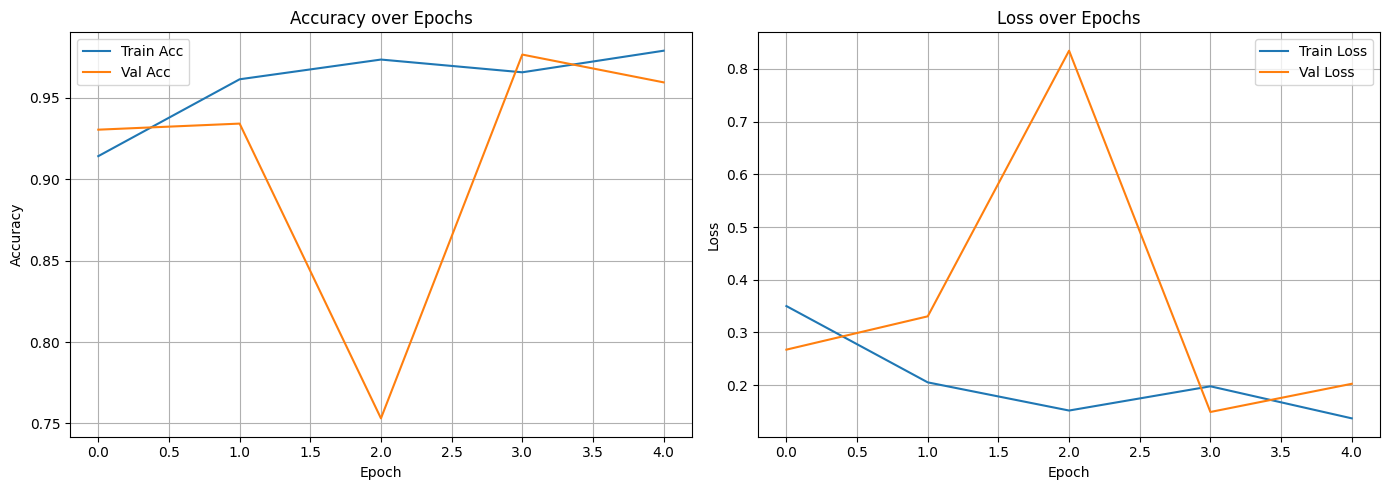

In [35]:
# ─────────────────────────────────────────────
# CELL 13 — Training curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [36]:
# ─────────────────────────────────────────────
# CELL 14 — Evaluate on TEST set
# ─────────────────────────────────────────────

# Collect true labels and predictions
y_true_all = []
y_pred_all = []

for i in tqdm(range(len(test_gen)), desc='Evaluating test set'):
    X_batch, y_batch = test_gen[i]
    preds = model.predict(X_batch, verbose=0)
    y_true_all.extend(np.argmax(y_batch, axis=1))
    y_pred_all.extend(np.argmax(preds,   axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

test_acc = accuracy_score(y_true_all, y_pred_all)
print(f"\n{'='*50}")
print(f"  TEST ACCURACY : {test_acc * 100:.2f}%")
print(f"{'='*50}")

print("\nClassification Report:")
print(classification_report(
    y_true_all, y_pred_all, target_names=CLASS_NAMES
))

Evaluating test set: 100%|██████████| 235/235 [02:28<00:00,  1.58it/s]


  TEST ACCURACY : 97.95%

Classification Report:
              precision    recall  f1-score   support

   No Cancer       0.97      0.98      0.98      1500
 Lung Cancer       1.00      0.99      1.00      1500
Colon Cancer       0.95      0.95      0.95       750

    accuracy                           0.98      3750
   macro avg       0.97      0.98      0.97      3750
weighted avg       0.98      0.98      0.98      3750



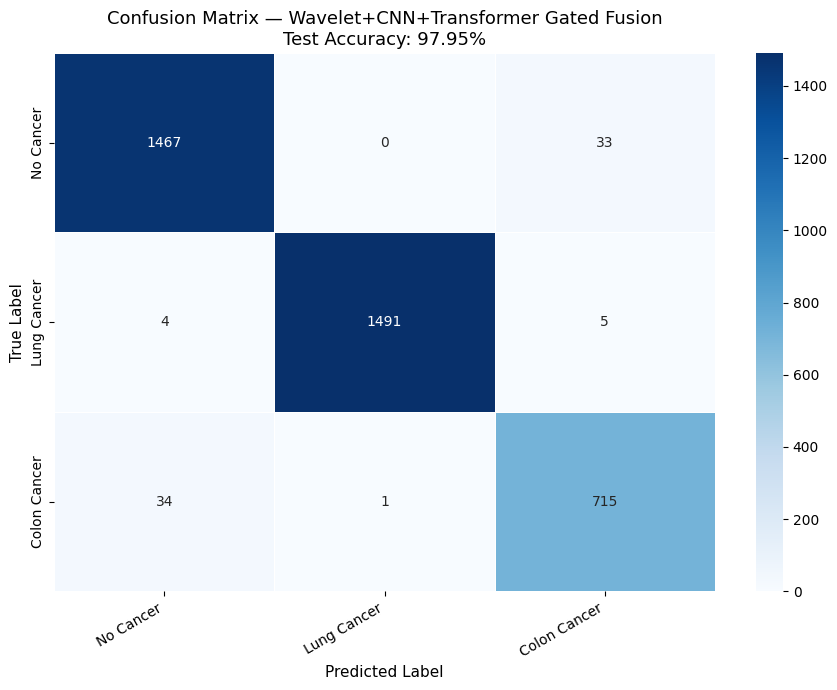

In [37]:
# ─────────────────────────────────────────────
# CELL 15 — Confusion Matrix
# ─────────────────────────────────────────────
cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title(
    f'Confusion Matrix — Wavelet+CNN+Transformer Gated Fusion\n'
    f'Test Accuracy: {test_acc * 100:.2f}%',
    fontsize=13
)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label',      fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [38]:
# ─────────────────────────────────────────────
# CELL 16 — Single image prediction
# ─────────────────────────────────────────────
def predict_single_image(model, img_path, show=True):
    """
    Predict the class of a single histopathological image.

    Parameters
    ----------
    model    : trained Keras model
    img_path : str — path to the image file
    show     : bool — display the image with prediction overlay

    Returns
    -------
    dict with 'predicted_class', 'confidence', 'class_probabilities'
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"[ERROR] Cannot load image: {img_path}")
        return None

    processed = wavelet_preprocess(img_bgr)
    inp = np.expand_dims(processed, axis=0)     # (1, 224, 224, 6)

    probs     = model.predict(inp, verbose=0)[0]
    class_idx = int(np.argmax(probs))
    predicted = CLASS_NAMES[class_idx]
    confidence = float(probs[class_idx])

    result = {
        'predicted_class':     predicted,
        'confidence':          confidence,
        'class_probabilities': {
            name: float(prob)
            for name, prob in zip(CLASS_NAMES, probs)
        }
    }

    if show:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

        plt.figure(figsize=(5, 5))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(
            f"Prediction : {predicted}\n"
            f"Confidence : {confidence * 100:.2f}%",
            fontsize=12, color='darkblue'
        )
        # Probability bar underneath title
        bar_text = "  |  ".join(
            [f"{n}: {p*100:.1f}%"
             for n, p in zip(CLASS_NAMES, probs)]
        )
        plt.xlabel(bar_text, fontsize=8)
        plt.tight_layout()
        plt.show()

    print(f"\nImage         : {os.path.basename(img_path)}")
    print(f"Prediction    : {predicted}")
    print(f"Confidence    : {confidence * 100:.2f}%")
    print("Probabilities :")
    for name, prob in zip(CLASS_NAMES, probs):
        bar = '█' * int(prob * 30)
        print(f"  {name:<15} {prob*100:6.2f}%  {bar}")

    return result


# ── Example usage (update path) ───────────────
# result = predict_single_image(
#     model,
#     "/path/to/your/image.jpeg"
# )

In [39]:
# ─────────────────────────────────────────────
# CELL 17 — Multiple image prediction (folder)
# ─────────────────────────────────────────────
def predict_folder(model, folder_path, show_samples=5):
    """
    Run inference on every image inside a folder.

    Parameters
    ----------
    model        : trained Keras model
    folder_path  : str — directory containing images
    show_samples : int — how many images to display (0 = none)

    Returns
    -------
    pandas DataFrame with Image, Prediction, Confidence columns
    """
    valid_ext = ('.png', '.jpg', '.jpeg')
    img_files = [
        f for f in sorted(os.listdir(folder_path))
        if f.lower().endswith(valid_ext)
    ]

    if not img_files:
        print(f"[WARNING] No images found in {folder_path}")
        return pd.DataFrame()

    results  = []
    display_count = 0

    print(f"Running inference on {len(img_files)} images ...")

    # Display a grid of sample predictions
    if show_samples > 0:
        n_show  = min(show_samples, len(img_files))
        fig, axes = plt.subplots(
            1, n_show, figsize=(4 * n_show, 4)
        )
        if n_show == 1:
            axes = [axes]

    for idx, img_name in enumerate(tqdm(img_files)):
        img_path = os.path.join(folder_path, img_name)
        img_bgr  = cv2.imread(img_path)
        if img_bgr is None:
            continue

        processed = wavelet_preprocess(img_bgr)
        inp       = np.expand_dims(processed, axis=0)
        probs     = model.predict(inp, verbose=0)[0]
        class_idx = int(np.argmax(probs))
        predicted = CLASS_NAMES[class_idx]
        confidence = float(probs[class_idx])

        results.append({
            'Image':       img_name,
            'Prediction':  predicted,
            'Confidence':  confidence,
            'No Cancer':   float(probs[0]),
            'Lung Cancer': float(probs[1]),
            'Colon Cancer':float(probs[2]),
        })

        # Show sample in grid
        if show_samples > 0 and display_count < show_samples:
            ax  = axes[display_count]
            rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
            ax.imshow(rgb)
            ax.axis('off')
            ax.set_title(
                f"{predicted}\n{confidence*100:.1f}%",
                fontsize=9
            )
            display_count += 1

    if show_samples > 0:
        plt.suptitle('Sample Predictions from Folder', fontsize=12)
        plt.tight_layout()
        plt.savefig('folder_predictions_sample.png', dpi=150)
        plt.show()

    df = pd.DataFrame(results)
    df = df.sort_values('Confidence', ascending=False).reset_index(drop=True)

    print("\nPrediction summary:")
    print(df['Prediction'].value_counts().to_string())
    return df


# ── Example usage (update path) ───────────────
# folder = "/path/to/batch/folder"
# df_results = predict_folder(model, folder, show_samples=5)
# df_results.head(20)


=== SINGLE IMAGE PREDICTION ===


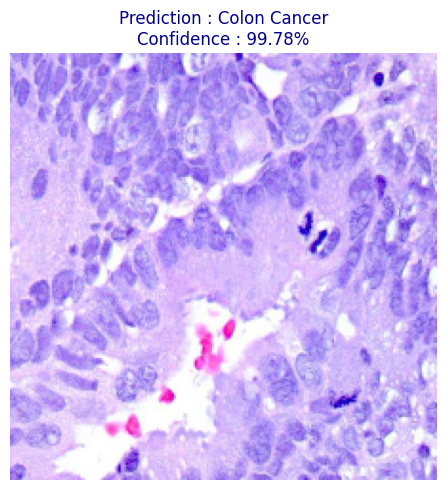


Image         : colonca3605.jpeg
Prediction    : Colon Cancer
Confidence    : 99.78%
Probabilities :
  No Cancer         0.07%  
  Lung Cancer       0.14%  
  Colon Cancer     99.78%  █████████████████████████████

=== FOLDER (MULTIPLE IMAGE) PREDICTION ===
Running inference on 12 images ...


100%|██████████| 12/12 [00:00<00:00, 13.76it/s]


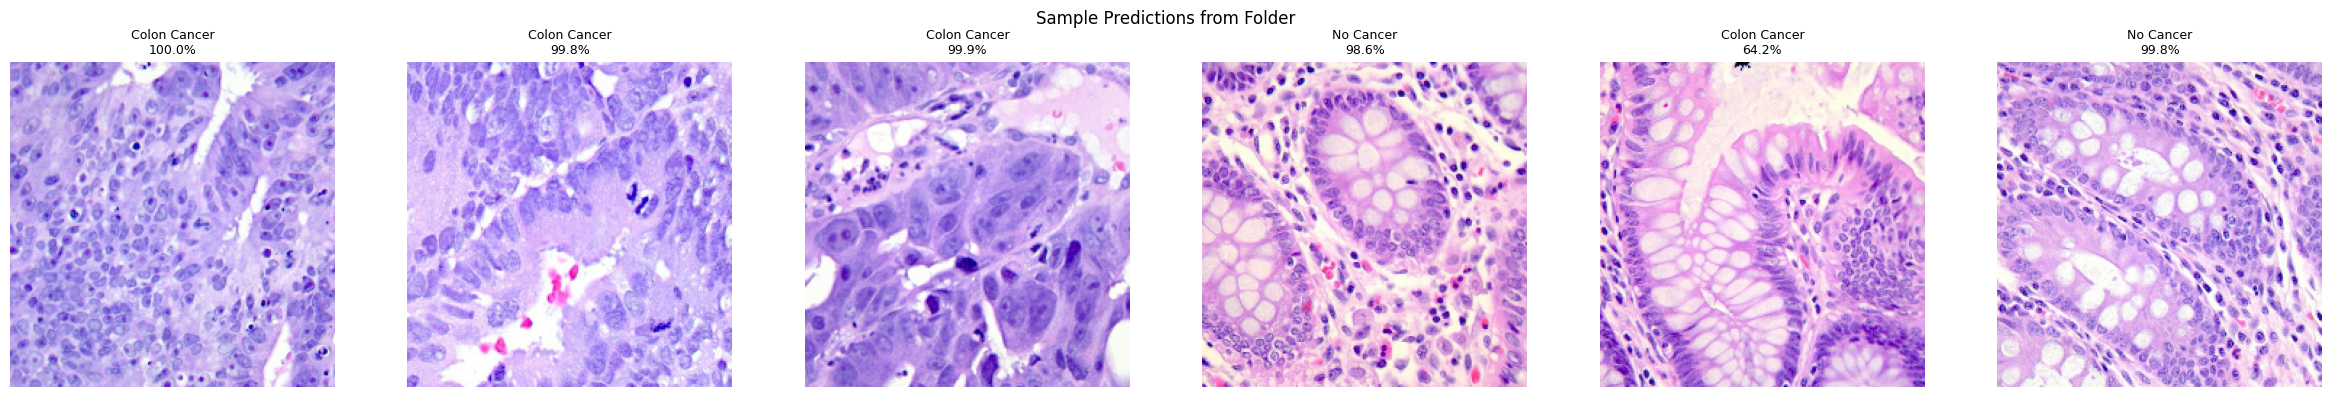


Prediction summary:
Prediction
Lung Cancer     5
Colon Cancer    4
No Cancer       3


,Image,Prediction,Confidence,No Cancer,Lung Cancer,Colon Cancer
0,lungscc3250.jpeg,Lung Cancer,1.000000,1.139455e-08,1.000000e+00,9.361895e-09
1,lungaca154.jpeg,Lung Cancer,0.999970,2.954660e-05,9.999702e-01,2.372025e-07
2,colonca2503.jpeg,Colon Cancer,0.999824,1.743755e-05,1.582146e-04,9.998243e-01
3,lungaca3197.jpeg,Lung Cancer,0.999750,2.482214e-04,9.997500e-01,1.762772e-06
4,lungscc1214.jpeg,Lung Cancer,0.999712,1.862333e-04,9.997119e-01,1.018072e-04
5,colonn1539.jpeg,No Cancer,0.999641,9.996407e-01,4.750027e-08,3.592851e-04
6,lungaca4205.jpeg,Lung Cancer,0.999030,9.455229e-04,9.990300e-01,2.457095e-05
7,colonca4533.jpeg,Colon Cancer,0.998725,1.207967e-03,6.708779e-05,9.987249e-01
8,colonca3605.jpeg,Colon Cancer,0.997844,7.363737e-04,1.419495e-03,9.978441e-01
9,colonn1486.jpeg,No Cancer,0.997598,9.975982e-01,1.184714e-07,2.401653e-03


In [40]:
# ─────────────────────────────────────────────
# CELL 18 — Quick demo using test images
#   (uses images already in the test split)
# ─────────────────────────────────────────────

# --- Single image demo ---
sample_img = X_test[0]
print("\n=== SINGLE IMAGE PREDICTION ===")
predict_single_image(model, sample_img)

# --- Folder demo: create a small temp folder from test images ---
import shutil, tempfile

tmp_dir = tempfile.mkdtemp(prefix='cancer_batch_')
sample_batch = X_test[:12]   # first 12 test images
for p in sample_batch:
    shutil.copy(p, tmp_dir)

print("\n=== FOLDER (MULTIPLE IMAGE) PREDICTION ===")
df_batch = predict_folder(model, tmp_dir, show_samples=6)
display(df_batch)

# Clean up temp folder
shutil.rmtree(tmp_dir)